# Análisis exploratorio de alojamientos de Airbnb

Este notebook analiza los alojamientos disponibles en Londres, Madrid, Milán,
Nueva York, Sídney y Tokio.

El objetivo es comprender la estructura de la oferta, la distribución de los
precios y las señales de actividad observadas, utilizando como guía las preguntas
de negocio definidas para el proyecto.

## Pregunta principal

¿Qué segmentos de oferta —ciudad, barrio y tipo de alojamiento— presentan un
posicionamiento interesante según el tamaño de la oferta, el precio y la actividad
observada, y qué características los diferencian?

Esta pregunta constituye un marco inicial. Podrá reformularse si el análisis revela
nuevos patrones, limitaciones o preguntas más relevantes.

## Alcance del análisis

El EDA se realizará mediante tres etapas:

1. Análisis univariante de las variables relevantes.
2. Análisis de relaciones, segmentos y anomalías.
3. Consolidación de los principales insights.

En el primer checkpoint se estudiará cada variable por separado para comprender su
distribución, frecuencia, dispersión y valores atípicos.


## Limitaciones iniciales

- Los precios están expresados en monedas locales no identificadas, por lo que los
  importes absolutos solo se compararán dentro de cada ciudad.
- Las reseñas representan actividad observada, pero no equivalen directamente a
  reservas, demanda u ocupación.
- `availability_365` no distingue entre fechas reservadas y bloqueadas.
- Tokio no incluye `availability_365` ni `calculated_host_listings_count`.
- La fecha de extracción de los datos no está disponible.
- Los valores extremos se analizarán, pero no se eliminarán automáticamente.
- Los archivos originales no serán modificados.

## 1. Carga y verificación de los datos

Antes de analizar las variables se cargan los seis archivos, se conserva la ciudad
de origen y se comprueba que los datos originales mantienen su integridad.

### 1.1 Estrategia de carga

Los seis archivos se conservan por separado para mantener su procedencia y sus
diferencias de esquema. A cada DataFrame se le añade una variable `city` derivada
del manifiesto.

Después se crea una vista conjunta únicamente en memoria. Esta vista facilita los
resúmenes y comparaciones entre ciudades, pero no reemplaza ni modifica los archivos
originales.

Las columnas ausentes en alguna ciudad se conservarán como valores nulos. Los precios
absolutos se analizarán dentro de cada ciudad porque no existe una moneda común
documentada.

In [1]:
from pathlib import Path

import pandas as pd

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

manifest_path = project_root / "data" / "manifest.csv"
manifest = pd.read_csv(manifest_path)

manifest[["city", "relative_path", "size_bytes"]]

,city,relative_path,size_bytes
0,London,data/raw/airbnb/london_airbnb.csv,11578155
1,Madrid,data/raw/airbnb/madrid_airbnb.csv,2801783
2,Milan,data/raw/airbnb/milan_airbnb.csv,2393568
3,New York,data/raw/airbnb/NY_airbnb.csv,7077973
4,Sydney,data/raw/airbnb/sydney_airbnb.csv,5504518
5,Tokyo,data/raw/airbnb/tokyo_airbnb.csv,1738173


In [2]:
datasets = {}

for record in manifest.itertuples(index=False):
    csv_path = project_root / record.relative_path

    city_data = pd.read_csv(
        csv_path,
        low_memory=False,
    )

    city_data = city_data.assign(city=record.city)
    datasets[record.city] = city_data

print(f"Ciudades cargadas: {len(datasets)}")

Ciudades cargadas: 6


In [3]:
analysis_data = pd.concat(
    datasets.values(),
    ignore_index=True,
    sort=False,
)

print(f"Dimensiones conjuntas: {analysis_data.shape}")

Dimensiones conjuntas: (220031, 17)


In [4]:
load_summary = pd.DataFrame(
    [
        {
            "city": city,
            "rows": len(city_data),
            "columns": len(city_data.columns),
        }
        for city, city_data in datasets.items()
    ]
)

assert len(datasets) == 6
assert len(analysis_data) == 220_031
assert analysis_data["id"].nunique() == len(analysis_data)

load_summary

,city,rows,columns
0,London,85068,17
1,Madrid,19618,17
2,Milan,18322,16
3,New York,48895,17
4,Sydney,36662,17
5,Tokyo,11466,15


### Evidencia reutilizada

El inventario técnico y la evaluación inicial de calidad se realizaron en
`01_data_inventory.ipynb` y `02_data_understanding.ipynb`.

De esos análisis se reutilizan las siguientes conclusiones:

- existen 220.031 anuncios distribuidos entre seis ciudades;
- se observaron 16 columnas distintas y 13 columnas comunes;
- Tokio no contiene `availability_365` ni `calculated_host_listings_count`;
- las variables de reseñas presentan valores ausentes esperados y algunas
  inconsistencias ya documentadas;
- existen precios cero y extremos, estancias mínimas superiores a 365 noches,
  diferencias de formato en `last_review` y un problema puntual de codificación.

Este notebook no repite el perfilado técnico. Utiliza esa evidencia como punto de
partida para responder las preguntas de negocio.

## 2. Análisis univariante

### 2.1 Tipo de alojamiento

**Pregunta:** ¿Qué modalidades de alojamiento predominan en el conjunto de datos?

`room_type` es una variable categórica nominal. Para comprender su distribución se
calcularán el número de anuncios y su porcentaje sobre los 220.031 registros.

En esta primera vista se analiza el conjunto completo. Las diferencias entre ciudades
se estudiarán posteriormente como segmentación, evitando mezclar el análisis
univariante con el análisis de relaciones.

In [5]:
import matplotlib.pyplot as plt

In [6]:
room_type_summary = (
    analysis_data["room_type"]
    .value_counts()
    .rename_axis("room_type")
    .reset_index(name="listing_count")
)

room_type_summary["share_percentage"] = (
    room_type_summary["listing_count"]
    / len(analysis_data)
    * 100
).round(2)

room_type_summary

,room_type,listing_count,share_percentage
0,Entire home/apt,128154,58.24
1,Private room,86512,39.32
2,Shared room,4012,1.82
3,Hotel room,1353,0.61


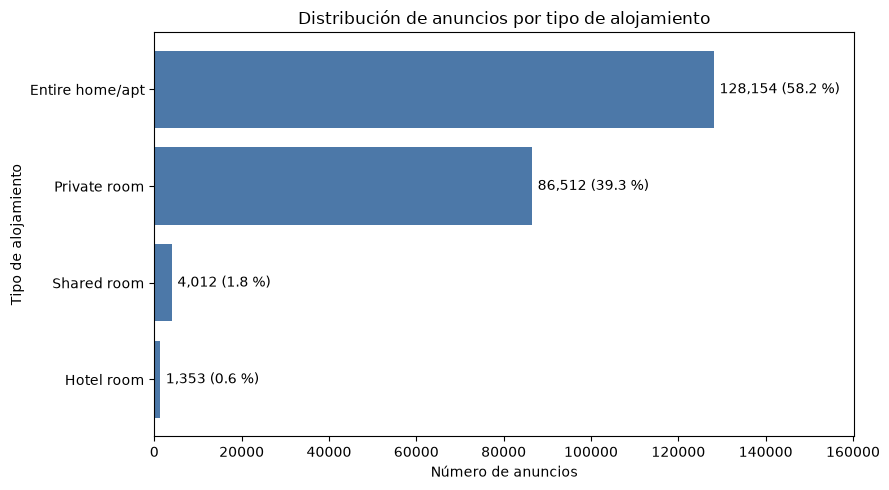

In [7]:
plot_data = room_type_summary.sort_values(
    "listing_count",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    plot_data["room_type"],
    plot_data["listing_count"],
    color="#4C78A8",
)

labels = [
    f"{count:,.0f} ({percentage:.1f} %)"
    for count, percentage in zip(
        plot_data["listing_count"],
        plot_data["share_percentage"],
    )
]

ax.bar_label(
    bars,
    labels=labels,
    padding=4,
)

ax.set_title("Distribución de anuncios por tipo de alojamiento")
ax.set_xlabel("Número de anuncios")
ax.set_ylabel("Tipo de alojamiento")
ax.set_xlim(
    0,
    plot_data["listing_count"].max() * 1.25,
)

plt.tight_layout()
plt.show()

### Interpretación del tipo de alojamiento

La categoría más frecuente es `Entire home/apt`, con 128.154 anuncios, que
representan el 58,24 % del conjunto analizado. Le sigue `Private room`, con 86.512
anuncios y un 39,32 %.

Ambas categorías reúnen conjuntamente el 97,56 % de los registros. `Shared room`
y `Hotel room` tienen una presencia minoritaria: suman únicamente el 2,43 %.

Por tanto, la oferta observada se estructura principalmente alrededor de viviendas
completas y habitaciones privadas, mientras que las habitaciones compartidas y los
alojamientos clasificados como hotel representan nichos reducidos.

Esta conclusión describe el conjunto de datos completo, no necesariamente cada
mercado local. Londres aporta una proporción especialmente elevada de los registros,
por lo que será necesario segmentar posteriormente por ciudad para comprobar si el
patrón se mantiene.

### 2.2 Precio

**Pregunta:** ¿Cómo se distribuyen los precios publicados dentro de cada ciudad?

Los precios no se analizarán conjuntamente porque están expresados en monedas locales
diferentes. Primero se calcularán medidas robustas por ciudad para comprender el
nivel central, la dispersión y la importancia de los valores extremos.

Se priorizan la mediana y los cuartiles frente a la media, porque los precios presentan
colas largas y valores extremos que pueden distorsionar el promedio.

In [8]:
price_summary = (
    analysis_data
    .groupby("city")["price"]
    .agg(
        listing_count="size",
        non_positive_count=lambda values: values.le(0).sum(),
        minimum="min",
        first_quartile=lambda values: values.quantile(0.25),
        median="median",
        third_quartile=lambda values: values.quantile(0.75),
        percentile_95=lambda values: values.quantile(0.95),
        maximum="max",
    )
    .round(2)
)

price_summary["interquartile_range"] = (
    price_summary["third_quartile"]
    - price_summary["first_quartile"]
)

price_summary

,listing_count,non_positive_count,minimum,first_quartile,median,third_quartile,percentile_95,maximum,interquartile_range
city,,,,,,,,,
London,85068,18,0,47.0,84.0,140.0,315.65,12345,93.0
Madrid,19618,8,0,35.0,58.0,100.0,350.00,9999,65.0
Milan,18322,0,8,50.0,73.5,110.0,286.95,11999,60.0
New York,48895,11,0,69.0,106.0,175.0,355.00,10000,106.0
Sydney,36662,9,0,80.0,136.0,223.0,599.00,14999,143.0
Tokyo,11466,4,0,6026.0,10007.0,17216.0,37015.00,1000046,11190.0


#### Distribución visual de los precios

Se utiliza un histograma independiente para cada ciudad porque los precios están
expresados en monedas locales diferentes.

La visualización se limita al percentil 95 de cada ciudad. El 5 % superior permanece
en los datos y está recogido en la tabla anterior, pero no se muestra para evitar que
los máximos extremos oculten la forma de la distribución habitual.

La línea discontinua representa la mediana de cada ciudad.

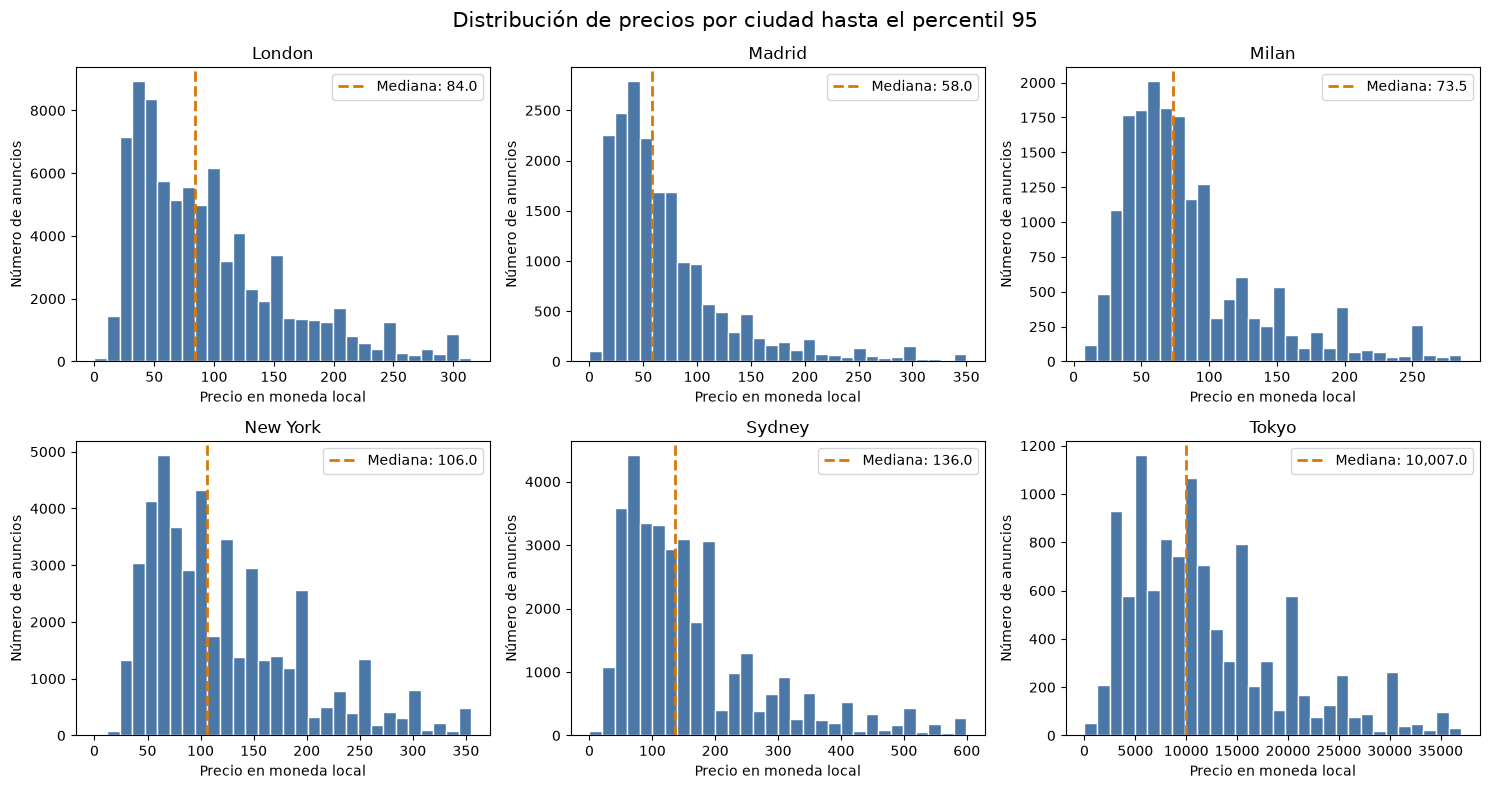

In [9]:
city_order = manifest["city"].tolist()

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8),
)

for ax, city in zip(axes.flat, city_order):
    city_prices = analysis_data.loc[
        analysis_data["city"].eq(city),
        "price",
    ]

    percentile_95 = city_prices.quantile(0.95)
    median_price = city_prices.median()

    visible_prices = city_prices[
        city_prices.between(0, percentile_95)
    ]

    ax.hist(
        visible_prices,
        bins=30,
        color="#4C78A8",
        edgecolor="white",
    )

    ax.axvline(
        median_price,
        color="#D97706",
        linestyle="--",
        linewidth=2,
        label=f"Mediana: {median_price:,.1f}",
    )

    ax.set_title(city)
    ax.set_xlabel("Precio en moneda local")
    ax.set_ylabel("Número de anuncios")
    ax.legend()

fig.suptitle(
    "Distribución de precios por ciudad hasta el percentil 95",
    fontsize=15,
)

plt.tight_layout()
plt.show()

Los archivos no incluyen el código de moneda asociado a `price`. Por este motivo,
no se asignan símbolos ni códigos monetarios a las ciudades y los importes absolutos
solo se interpretan dentro de cada dataset.

Las diferencias numéricas entre ciudades no deben entenderse como diferencias reales
de coste hasta disponer de la moneda y una referencia temporal verificadas.